# Mesh convergence: how fine is fine enough?

Every number the eigenmode solver reports is a discretisation of the real cavity, so the
first question about any of them is how much of it is the mesh. Here the cavity is a closed
metal cylinder, whose TM$_{010}$ frequency is known in closed form, so the error is measured
rather than estimated. The answer generalises: reach for the polynomial order before the
element size.

In [1]:
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import jn_zeros

from cavsim2d import Beampipe, Pillbox
from cavsim2d.constants import c0
from cavsim2d.utils.printing import set_verbose
from cavsim2d.utils.style import apply_style, WARM

set_verbose(False)
apply_style()
WORK = tempfile.mkdtemp()

## 1. A cylinder with a known answer

The TM$_{010}$ frequency of a closed cylinder of radius $R$ is
$f = c_0\,\chi_{01} / (2\pi R)$, with $\chi_{01}=2.405$ the first zero of $J_0$, whatever
its length. A `Beampipe` with metal (`'pec'`) end faces is exactly that cylinder.

In [2]:
R, L = 230.0, 200.0                         # mm
chi01 = jn_zeros(0, 1)[0]
f_analytic = c0 * chi01 / (2 * np.pi * R * 1e-3) * 1e-6   # MHz
print(f'analytic TM010 = {f_analytic:.6f} MHz')

cav = Beampipe(R, L, ends='pec', name='cylinder')
cav.set_workspace(os.path.join(WORK, cav.name))

analytic TM010 = 498.880556 MHz


Beampipe(name='cylinder', n_cells=1, beampipe='none')

## 2. Run the convergence sweep

Solve the monopole modes at polynomial orders $p = 2$ to $6$. At each order the mesh starts
from elements as large as the cylinder allows, `h = 250` mm, a handful of triangles, and is
refined adaptively, where the error is largest, until the modes stop moving or the DOF cap
is reached. Starting that coarse is what lets the high orders show a convergence curve at
all: on a finer first mesh they are already at the precision of the arithmetic.

In [3]:
cav.study_mesh_convergence(
    h=250, p=2, p_passes=5, p_step=1,
    n_modes=4, polarisation=('monopole',),
    max_refinements=8, max_ndof=100000,
)
df = cav.convergence_df_data
df[['p', 'h_pass', 'No of DOFs', 'freq [MHz]', 'max_err']].head(12)

C:\Users\Soske\Documents\git_projects\cavsim2d\cavsim2d\solvers\NGSolve\eigen_ngsolve.py:2706: PeakPropertyWarning: some peaks have a width of 0
  peaks, _ = find_peaks(Ez_axis, distance=max(1, n_ax_pts // 100), width=width)


,p,h_pass,No of DOFs,freq [MHz],max_err
0,2,0,37,501.004976,0.269940
1,2,0,37,909.344196,0.286055
2,2,0,37,1157.156020,1.700538
3,2,0,37,1200.152699,9.289887
4,2,1,126,499.080162,0.022367
5,2,1,126,903.682371,0.916978
6,2,1,126,1094.926561,0.003508
7,2,1,126,1156.011646,4.927878
8,2,2,454,498.893797,0.000212
9,2,2,454,900.561328,0.021646


## 3. Convergence of the fundamental

The fundamental's relative error against the closed form, against the number of degrees of
freedom, one curve per polynomial order. Each triangle is fitted to its curve above the
round-off floor and labelled with the slope, the rate at which the error falls as unknowns
are added. Theory predicts $p$: the eigenvalue error of order-$p$ elements falls as
$h^{2p}$, and in two dimensions the number of unknowns grows as $h^{-2}$. Below about
$10^{-14}$ the error has reached the precision of the arithmetic, and the curves go flat.

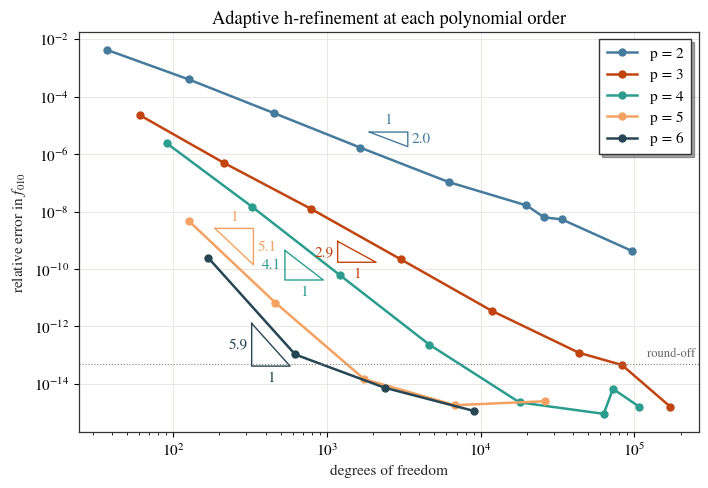

fitted rates: {2: 2.0, 3: 2.9, 4: 4.1, 5: 5.1, 6: 5.9}


In [4]:
ROUND_OFF = 5e-14


def slope_triangle(ax, x, y, color, where, side, width=0.25):
    # A right triangle beside a log-log curve, its hypotenuse parallel to a least-squares
    # fit of the points above round-off, labelled with the fitted rate. *where* is the
    # position along the fitted range (0 to 1) and *side* whether it sits above or below
    # the curve.
    x, y = np.asarray(x, float), np.asarray(y, float)
    keep = y > ROUND_OFF
    if keep.sum() < 2:
        return None
    lx, ly = np.log10(x[keep]), np.log10(y[keep])
    k, c = np.polyfit(lx, ly, 1)
    x0 = 10 ** (lx.min() + where * (lx.max() - lx.min()))
    x1 = x0 * 10 ** width
    shift = 4.0 if side == 'above' else 0.25
    y0 = 10 ** (c + k * np.log10(x0)) * shift
    y1 = y0 * (x1 / x0) ** k
    if side == 'above':      # corner top-right: "1" along the top, the rate on the right
        ax.plot([x0, x1, x1, x0], [y0, y0, y1, y0], color=color, lw=1)
        ax.text(np.sqrt(x0 * x1), y0 * 1.5, '1', color=color, ha='center', va='bottom')
        ax.text(x1 * 1.06, np.sqrt(y0 * y1), f'{-k:.1f}', color=color, ha='left', va='center')
    else:                    # corner bottom-left: the rate on the left, "1" along the bottom
        ax.plot([x0, x1, x0, x0], [y0, y1, y1, y0], color=color, lw=1)
        ax.text(x0 / 1.06, np.sqrt(y0 * y1), f'{-k:.1f}', color=color, ha='right', va='center')
        ax.text(np.sqrt(x0 * x1), y1 / 1.5, '1', color=color, ha='center', va='top')
    return -k


# where each triangle sits, chosen to keep it clear of the neighbouring curves
PLACE = {2: (0.5, 'above'), 3: (0.45, 'below'), 4: (0.45, 'below'), 5: (0.3, 'above'),
         6: (0.5, 'below')}


fund = df[df['mode_index'] == '0-0'].copy()
fund['rel_err'] = ((fund['freq [MHz]'] - f_analytic).abs() / f_analytic).clip(lower=1e-16)

fig, ax = plt.subplots(figsize=(8, 5.2))
rates = {}
for i, (p, g) in enumerate(fund.groupby('p')):
    g = g.sort_values('No of DOFs')
    ax.plot(g['No of DOFs'], g['rel_err'], marker='o', ms=5,
            color=WARM[i % len(WARM)], label=f'p = {p}')
    rates[p] = slope_triangle(ax, g['No of DOFs'], g['rel_err'], WARM[i % len(WARM)],
                              *PLACE.get(p, (0.5, 'below')))
ax.axhline(ROUND_OFF, color='0.5', lw=0.8, ls=':')
ax.set_xscale('log'); ax.set_yscale('log')
ax.text(ax.get_xlim()[1], ROUND_OFF * 1.4, 'round-off ', color='0.4', ha='right',
        va='bottom', fontsize=9)
ax.set_xlabel('degrees of freedom'); ax.set_ylabel('relative error in $f_{010}$')
ax.set_title('Adaptive h-refinement at each polynomial order')
ax.legend()
plt.show()
print('fitted rates:', {int(p): round(r, 1) for p, r in rates.items() if r})

The fitted rates are 2.0, 2.9, 4.1, 5.1 and 5.9 for $p = 2$ to $6$: every order converges at
the rate theory predicts for it. Each step up in order adds one to the rate, which is why the
higher orders are so much cheaper for the same accuracy. Their curves do not just start
lower, they fall faster.

## 4. How fine is fine enough?

The fewest DOFs at which each order reaches a given accuracy.

In [5]:
rows = {}
for p, g in fund.groupby('p'):
    g = g.sort_values('No of DOFs')
    rows[p] = {f'DOFs to {tol:.0e}': (int(g.loc[g['rel_err'] <= tol, 'No of DOFs'].min())
                                      if (g['rel_err'] <= tol).any() else None)
               for tol in (1e-6, 1e-9, 1e-12)}
    rows[p]['best error'] = g['rel_err'].min()
table = pd.DataFrame(rows).T
table.index.name = 'p'
table

,DOFs to 1e-06,DOFs to 1e-09,DOFs to 1e-12,best error
p,,,,
2,6212.0,96520.0,NaN,4.255973e-10
3,214.0,3022.0,43684.0,1.595187e-15
4,326.0,1222.0,4636.0,9.115355e-16
5,127.0,462.0,1750.0,1.823071e-15
6,169.0,169.0,622.0,1.139419e-15


To part-per-billion accuracy ($10^{-9}$), $p = 2$ needs 97 000 DOFs, $p = 3$ 3 000, $p = 4$
1 200, $p = 5$ 460 and $p = 6$ 170: some 570 times fewer unknowns from the lowest order to
the highest. At $10^{-12}$ the quadratic elements never arrive within the cap, while $p = 6$
needs 620 DOFs. Raise the order before refining the mesh.

## 5. Compare like with like

A small change to the geometry is a different cavity, with a different frequency. Put a
1 mm hole on the axis of each end face, which is what a `Pillbox` with a 1 mm iris radius
is, and solve it on a fine mesh:

In [6]:
holed = Pillbox(1, [L, R, 1.0, 0.0, 0.0], beampipe='none')
holed.name = 'cylinder_with_1mm_holes'
holed.set_workspace(os.path.join(WORK, holed.name))
holed.eigenmode.run({'mesh_config': {'h': 25, 'p': 5}, 'n_modes': 2, 'processes': 1})
f_holed = holed.eigenmode.qois['freq [MHz]']
print(f'with 1 mm holes: {f_holed:.6f} MHz, {abs(f_holed / f_analytic - 1):.1e} from the closed cylinder')

with 1 mm holes: 498.880625 MHz, 1.4e-07 from the closed cylinder


The holes move the frequency by $1.4\times10^{-7}$, far above the error every order reaches
in section 3. Measured against the closed-form answer for the closed cylinder, every order
would seem to stop converging at that level, which reads as a limit of the solver when it is
the difference between two cavities. Before taking a floor in a convergence study as
numerical, check that the reference describes exactly the geometry that was meshed.

## Where to go next

- [Convergence of every figure of merit](convergence_qois.ipynb): the same question for
  R/Q, G, the peak fields, coupling and field flatness on a real cavity.
- [Solver settings: time against accuracy](solver_settings.ipynb): what the eigensolver's
  own settings cost and buy on a fixed mesh.
- [The pillbox / circular waveguide](../eigenmode/pillbox.ipynb): the same cylinder,
  checked against the closed form for 900 modes.
- Pass `mesh_config={'h': ..., 'p': ..., 'adaptive': True}` to any
  `cav.eigenmode.run(...)` to refine a single solve adaptively.